H2 demand data: Reading

In [297]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import yaml
import itertools


In [298]:
def h2_pypsa(config_path, pypsa_path, country):
    h2_demand = pd.DataFrame()

    files = sorted([f for f in os.listdir(f"{config_path}") if os.path.isfile(os.path.join(f"/{config_path}", f))])

    for config_file in files:
        with open(f"{config_path}/{config_file}") as file:
            config = yaml.safe_load(file)
        
        run_name = config["run"]["name"]
        clusters = config["scenario"]["clusters"][0]
        sectors_opts = config["scenario"]["sector_opts"][0]
        planing_horizon = config["scenario"]["planning_horizons"]

        for year in planing_horizon:
            n = pypsa.Network(f"{pypsa_path}/{run_name}/networks/base_s_{clusters}__{sectors_opts}_{year}.nc")
            
            if country == "EU":
                df_h2 = n.statistics.energy_balance()
                idx = pd.IndexSlice
                df_h2 = df_h2.loc[idx[:,:,"Hydrogen Storage"]].div(1e6)
            else:
                df_h2 = n.statistics.energy_balance(groupby=["carrier", "bus_carrier", "country"])
                idx = pd.IndexSlice
                df_h2 = df_h2.loc[idx[:,:,"Hydrogen Storage",country]].div(1e6)
            
            new_data = pd.DataFrame([{ 
                "Year of H2 demand": int(year),
                "Value": abs(df_h2[df_h2 < 0].sum()),  
                "Abbreviation": run_name.split("-2025-2050-5-T-H-B-I-A")[0]
            }])

            h2_demand = pd.concat([h2_demand, new_data], ignore_index=True)

    h2_demand = h2_demand.pivot(index="Year of H2 demand", columns="Abbreviation", values="Value")
    h2_demand.index.name = None
    h2_demand.columns.name = None

    return h2_demand

In [299]:
H2_Demand = os.path.join("H2-Demand.csv")
H2_Demand = pd.read_csv(H2_Demand, sep=";", decimal=",")

config_path = "/mnt/e/H2GMA/Github/Europe/analyse-h2g-a-ap3-eu/config/test"
pypsa_path = "/mnt/e/H2GMA/Github/Europe/pypsa-eur/results/myopic/"

H2 demand data Germany: Preparation

In [300]:
H2_Demand_Germany = H2_Demand.loc[H2_Demand['Location'] == 'Germany']

Year = H2_Demand_Germany["Year of H2 demand"].drop_duplicates()
Year.sort_values(ascending=True, inplace=True)

Abbreviation = H2_Demand_Germany["Abbreviation"].drop_duplicates()
Abbreviation.sort_values(ascending=True, inplace=True)

H2_Demand_Germany_Plot = pd.DataFrame(index=list(Year), columns=list(Abbreviation))

for a, b in H2_Demand_Germany_Plot.iterrows():      
      for c, d in H2_Demand_Germany_Plot.items():
            if H2_Demand_Germany[(H2_Demand_Germany["Year of H2 demand"] == a) & (H2_Demand_Germany["Abbreviation"] == c)].empty == False:
                  H2_Demand_Germany_Help = H2_Demand_Germany[(H2_Demand_Germany["Year of H2 demand"] == a) & (H2_Demand_Germany["Abbreviation"] == c)]["Value"].reset_index() 
                  H2_Demand_Germany_Plot.loc[a][c] = H2_Demand_Germany_Help.loc[0, "Value"]



/tmp/ipykernel_20101/713236126.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  H2_Demand_Germany_Plot.loc[a][c] = H2_Demand_Germany_Help.loc[0, "Value"]
/tmp/ipykernel_20101/713236126.py:15: FutureWarning: ChainedAssignmentError: behavi

H2 demand data Germany: Plotting

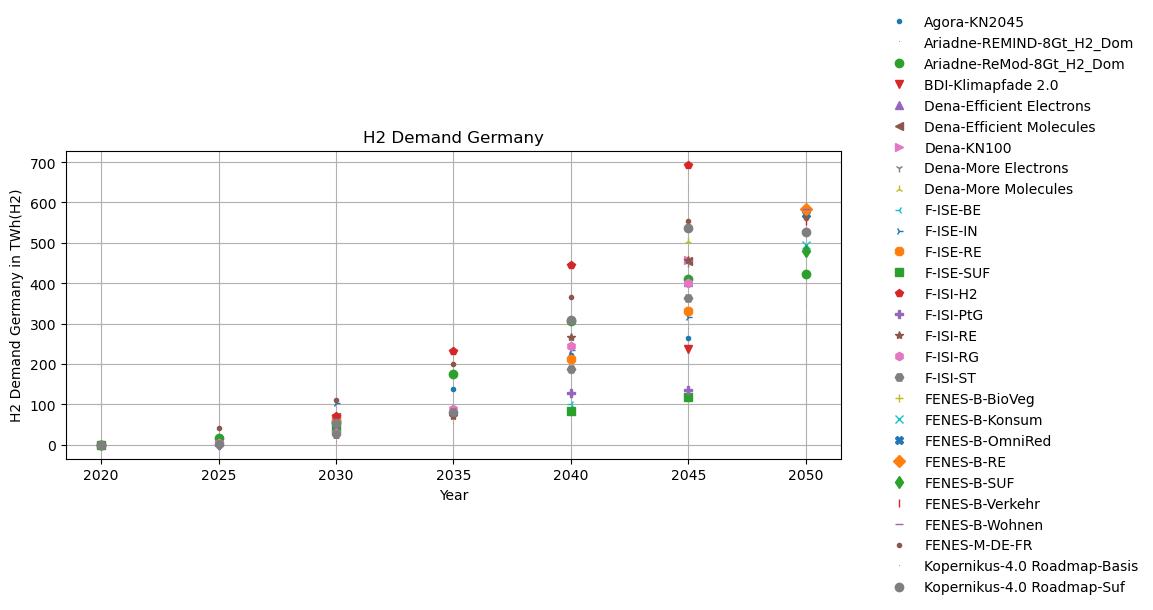

In [301]:
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",".",",","o"]
H2_Demand_Germany_Plot.plot(style=markers, figsize=(10,4))

#NUM_COLORS = len(H2_Demand_Germany_Plot.columns)
#colors = sns.color_palette("husl", n_colors=NUM_COLORS)
#H2_Demand_Germany_Plot.plot(style=".", color=colors, figsize=(10,4))

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Germany in TWh(H2)")
plt.title("H2 Demand Germany")

plt.show()

In [302]:
country = "DE"

In [303]:
h2_demand_pypsa = h2_pypsa(config_path, pypsa_path, country)

H2_Demand_Germany_all = H2_Demand_Germany_Plot.merge(h2_demand_pypsa, left_index=True, right_index=True, how="left")

INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


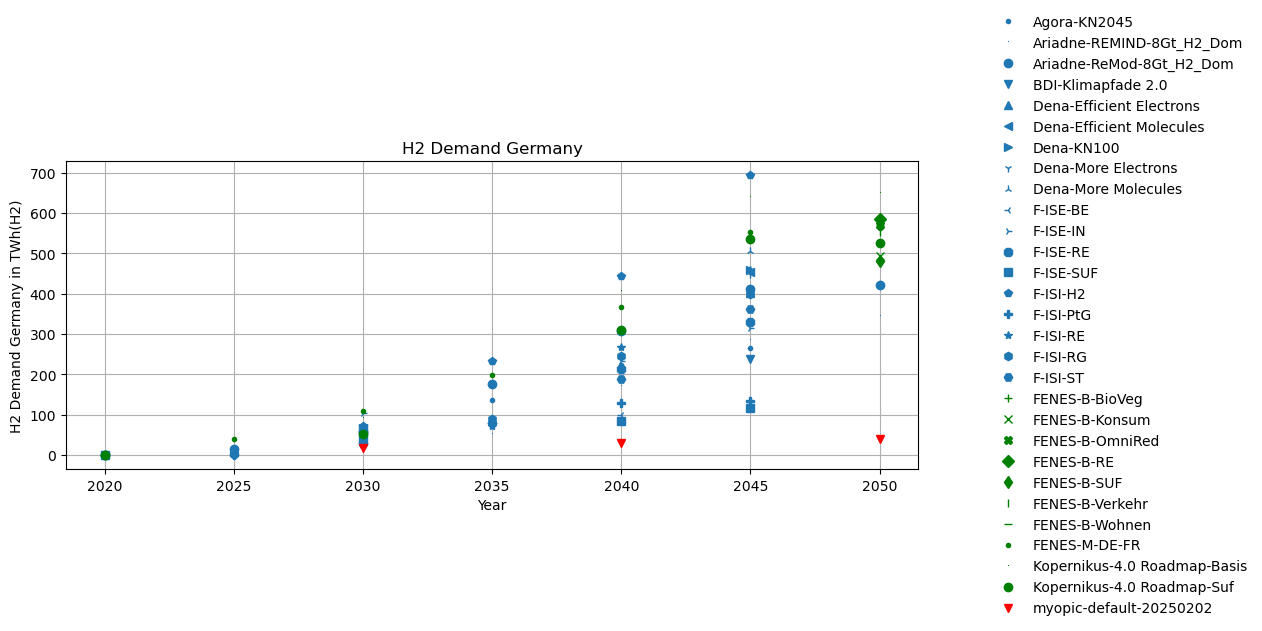

In [304]:
# Define marker and color combinations
unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Germany_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

for (col, (color, marker)) in zip(H2_Demand_Germany_all.columns, styles):
    if "myopic" in col:  # Corrected substring check
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color="red", markersize=6, label=col)
    elif "FENES" in col or "Kopernikus" in col:
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color="green", markersize=6, label=col)
    else:
        H2_Demand_Germany_all[col].plot(ax=ax, linestyle="None", marker=marker, color=color, markersize=6, label=col)

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Germany in TWh(H2)")
plt.title("H2 Demand Germany")
plt.show()


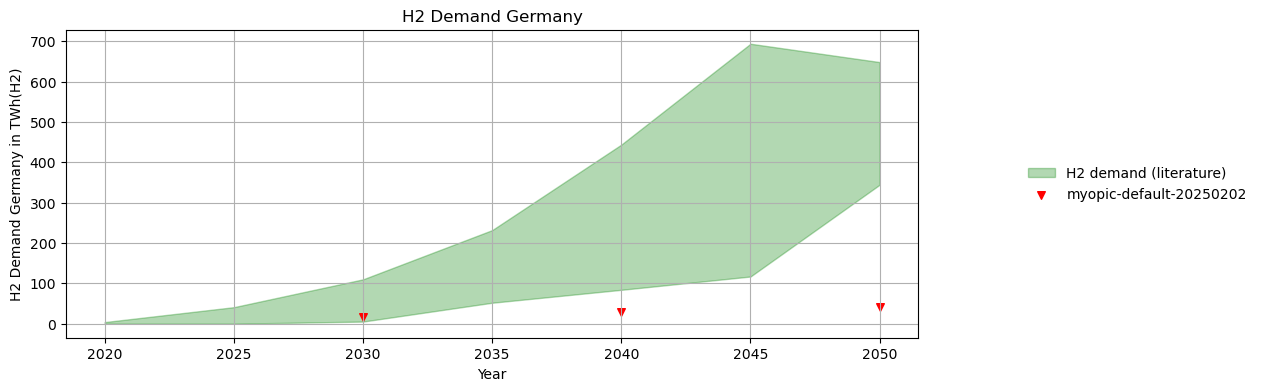

In [305]:
# Define marker and color combinations
H2_Demand_Germany_all = H2_Demand_Germany_all.apply(pd.to_numeric, errors='coerce')
H2_Demand_Germany_Plot = H2_Demand_Germany_Plot.apply(pd.to_numeric, errors='coerce')

unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Germany_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

lower_bound = H2_Demand_Germany_Plot.min(axis=1, skipna=True)
upper_bound = H2_Demand_Germany_Plot.max(axis=1, skipna=True)

ax.fill_between(H2_Demand_Germany_all.index, lower_bound, upper_bound, color='green', alpha=0.3, label="H2 demand (literature)")

# Plot each scenario separately
for (col, (color, marker)) in zip(H2_Demand_Germany_all.columns, styles):
    if "myopic" in col.lower():  # Case-insensitive check for "myopic"
        ax.scatter(H2_Demand_Germany_all.index, H2_Demand_Germany_all[col], color="red", marker=marker, s=30, label=col)

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Germany in TWh(H2)")
plt.title("H2 Demand Germany")
plt.show()


H2 demand data Europe: Preparation

In [306]:
H2_Demand_Europe = H2_Demand.loc[H2_Demand['Location'] == 'Europe']

Year = H2_Demand_Europe["Year of H2 demand"].drop_duplicates()
Year.sort_values(ascending=True, inplace=True)

Abbreviation = H2_Demand_Europe["Abbreviation"].drop_duplicates()
Abbreviation.sort_values(ascending=True, inplace=True)

H2_Demand_Europe_Plot = pd.DataFrame(index=list(Year), columns=list(Abbreviation))

for a, b in H2_Demand_Europe_Plot.iterrows():      
      for c, d in H2_Demand_Europe_Plot.items():
            if H2_Demand_Europe[(H2_Demand_Europe["Year of H2 demand"] == a) & (H2_Demand_Europe["Abbreviation"] == c)].empty == False:
                  H2_Demand_Europe_Help = H2_Demand_Europe[(H2_Demand_Europe["Year of H2 demand"] == a) & (H2_Demand_Europe["Abbreviation"] == c)]["Value"].reset_index() 
                  H2_Demand_Europe_Plot.loc[a][c] = H2_Demand_Europe_Help.loc[0, "Value"]

/tmp/ipykernel_20101/514307443.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  H2_Demand_Europe_Plot.loc[a][c] = H2_Demand_Europe_Help.loc[0, "Value"]
/tmp/ipykernel_20101/514307443.py:15: FutureWarning: ChainedAssignmentError: behaviou

H2 demand data Europe: Plotting

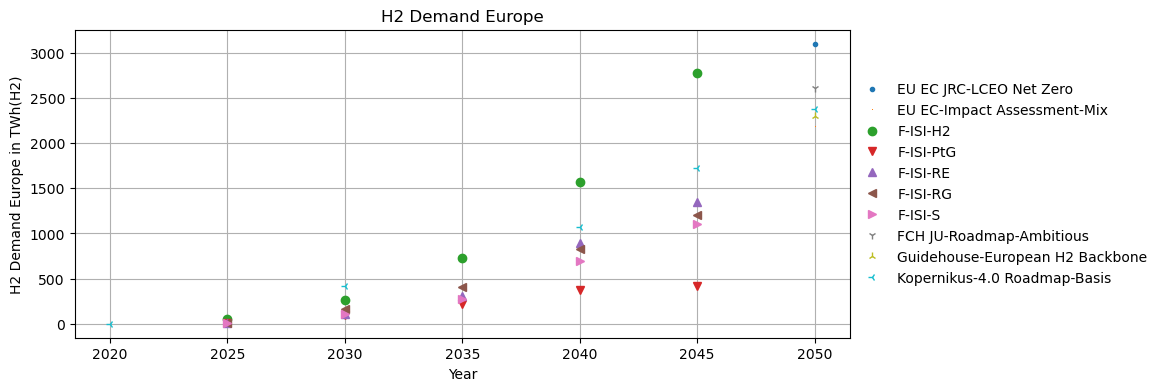

In [307]:
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",".",",","o"]
H2_Demand_Europe_Plot.plot(style=markers, figsize=(10,4))

#H2_Demand_Europe_Plot.plot(style=".", figsize=(10,4))

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Europe in TWh(H2)")
plt.title("H2 Demand Europe")

plt.show()

In [308]:
country = "EU"

In [309]:
h2_demand_pypsa = h2_pypsa(config_path, pypsa_path, country)

H2_Demand_Europe_all = H2_Demand_Europe_Plot.merge(h2_demand_pypsa, left_index=True, right_index=True, how="left")

INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_39__144H-T-H-B-I-A_2050.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


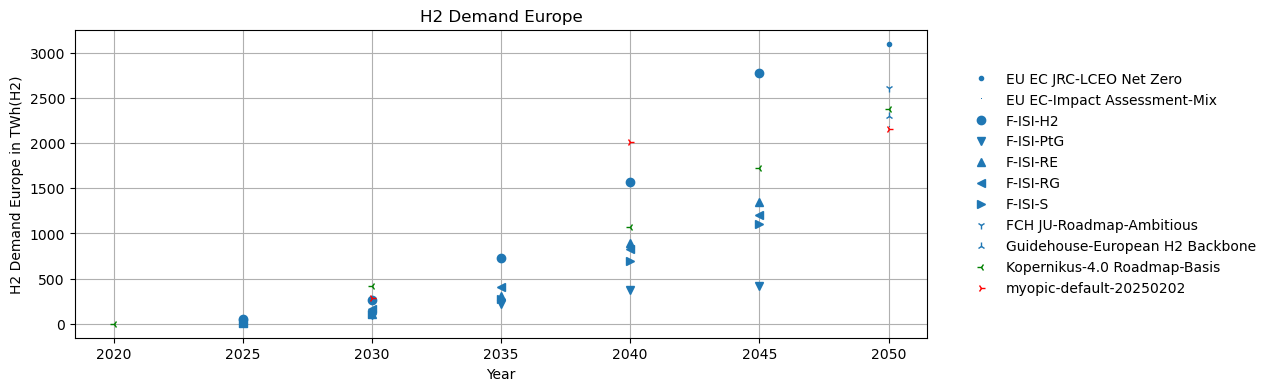

In [310]:
# Define marker and color combinations
unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Europe_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

for (col, (color, marker)) in zip(H2_Demand_Europe_all.columns, styles):
    if "myopic" in col:  # Corrected substring check
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color="red", markersize=6, label=col)
    elif "FENES" in col or "Kopernikus" in col:
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color="green", markersize=6, label=col)
    else:
        H2_Demand_Europe_all[col].plot(ax=ax, linestyle="None", marker=marker, color=color, markersize=6, label=col)

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Europe in TWh(H2)")
plt.title("H2 Demand Europe")
plt.show()


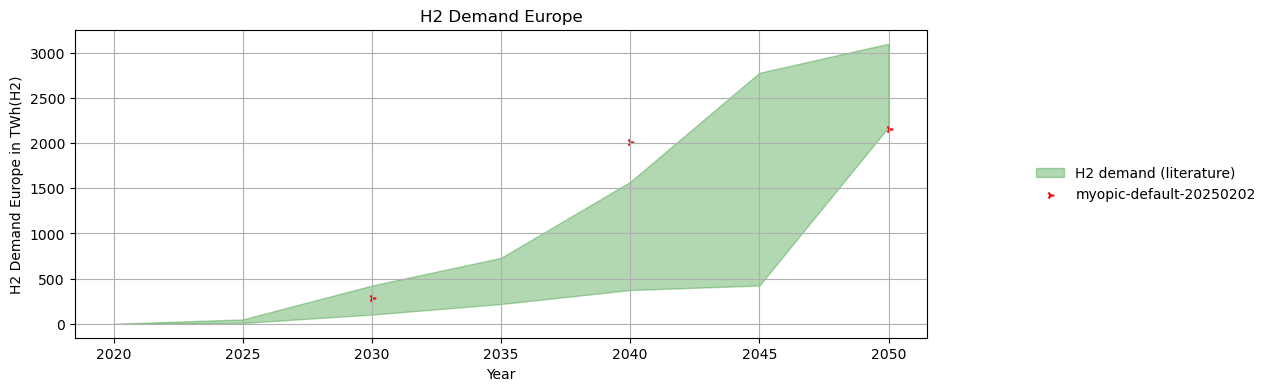

In [311]:
# Define marker and color combinations
H2_Demand_Europe_all = H2_Demand_Europe_all.apply(pd.to_numeric, errors='coerce')
H2_Demand_Europe_Plot = H2_Demand_Europe_Plot.apply(pd.to_numeric, errors='coerce')

unique_markers = [".", ",", "o", "v", "^", "<", ">", "1", "2", "3", "4", "8", "s", "p", "P", "*", "h", "H", "+", "x", "X", "D", "d", "|", "_"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Get default color cycle

# Generate a list of (color, marker) combinations
style_combinations = list(itertools.product(colors, unique_markers))

# Cycle through styles if there are more columns than styles
styles = list(itertools.islice(itertools.cycle(style_combinations), len(H2_Demand_Europe_all.columns)))

# Plot each column separately with its (color, marker) pair
fig, ax = plt.subplots(figsize=(11, 4))

lower_bound = H2_Demand_Europe_Plot.min(axis=1, skipna=True)
upper_bound = H2_Demand_Europe_Plot.max(axis=1, skipna=True)

ax.fill_between(H2_Demand_Europe_all.index, lower_bound, upper_bound, color='green', alpha=0.3, label="H2 demand (literature)")

# Plot each scenario separately
for (col, (color, marker)) in zip(H2_Demand_Europe_all.columns, styles):
    if "myopic" in col.lower():  # Case-insensitive check for "myopic"
        ax.scatter(H2_Demand_Europe_all.index, H2_Demand_Europe_all[col], color="red", marker=marker, s=30, label=col)

plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xlabel("Year")
plt.grid()
plt.ylabel("H2 Demand Europe in TWh(H2)")
plt.title("H2 Demand Europe")
plt.show()